In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from scipy.special import expit as sigmoid
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import Ridge, LinearRegression
from tqdm import tqdm

In [2]:
from utils import DataHandler
from ESN import ESNetwork, ClassicalRC
from reservoirs import CPRC
from circuits import CPCircuit

In [3]:
train = pd.read_csv("DailyDelhiClimateTrain.csv",parse_dates=["date"], index_col="date").sort_index(inplace=False)
test = pd.read_csv("DailyDelhiClimateTest.csv",parse_dates=["date"], index_col="date").sort_index(inplace=False)

In [4]:
features = ['meantemp', 'humidity', 'wind_speed', 'meanpressure']

In [5]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler((0,1))
train_scaled = scaler.fit_transform(train[features])
test_scaled = scaler.transform(test[features])

In [6]:
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length][0])
    return np.array(X), np.array(y)

In [7]:
def create_test_sequences(train_tail, test_data, seq_length):
    full = np.concatenate([train_tail[-seq_length:], test_data], axis=0)
    X = []
    for i in range(len(test_data)):
        X.append(full[i:i+seq_length])
    return np.array(X)

In [8]:
SEQ_LEN = 6
X_train_, y_train = create_sequences(train_scaled, SEQ_LEN)

In [9]:
X_test_ = create_test_sequences(train_scaled, test_scaled, SEQ_LEN)
X_train__ = X_train_.reshape((X_train_.shape[0], SEQ_LEN, len(features)))
X_test__ = X_test_.reshape((X_test_.shape[0], SEQ_LEN, len(features)))

y_test = test_scaled[:, 0]  # Column 0 = meantemp
y_test = y_test[:X_test__.shape[0]]

In [10]:
X_train = [sample.flatten() for sample in X_train__]
X_test = [sample.flatten() for sample in X_test__]

In [11]:
X_train[1]

array([0.04279476, 0.90759076, 0.07058266, 0.132881  , 0.0356623 ,
       0.84983498, 0.10974262, 0.13299381, 0.08151383, 0.66886689,
       0.02921206, 0.13279856, 0.        , 0.84790979, 0.08763619,
       0.13271178, 0.03056769, 0.80132013, 0.03505448, 0.13290703,
       0.03056769, 0.75280528, 0.14921838, 0.13316737])

In [12]:
window_size = SEQ_LEN*4

In [13]:
from joblib import Parallel, delayed, parallel_backend
from itertools import product

def evaluate_alpha_limit(alpha_value, limit_value):
    try:
        cprc = CPRC(dim=window_size, execution_mode='simulation', kernel=True)

        esn = ESNetwork(
            reservoir=cprc,
            dim=window_size,
            regularization=1e-6,
            alpha=alpha_value,
            show_progress=False,
            approach='feedback',
            model_type='ridge',
            limit=limit_value,
            cpk=True
        )

        esn.fit(X_train, y_train)
        predictions = esn.predict(X_test)
        mse = mean_squared_error(y_test, predictions)
        a = 0
        b = 50
        # Plot Predictions
        plt.plot(y_test[a:a+b], label="True")
        plt.plot(predictions[a:a+b], label="Quantum ESN")
        plt.title("Quantum ESN Predictions with CPKernel Based Reservoir Computing")
        plt.legend()
        plt.savefig(f"alpha_{alpha_value}_limit_{limit_value}_rmse_{mse}.png")
        plt.show()
        return alpha_value, limit_value, mse

    except Exception as e:
        return alpha_value, limit_value, f"Error: {e}"


In [14]:
# Define your grid
alpha_list = np.linspace(0.1, 1.0, 20)
limit_list = np.linspace(0.01, 1.0, 10)
param_grid = list(product(alpha_list, limit_list))  # all combinations

In [15]:
with parallel_backend("loky", n_jobs=-1):  # use all cores
    results = Parallel()(
        delayed(evaluate_alpha_limit)(alpha, limit) for alpha, limit in tqdm(param_grid)
    )


00%|███████████████████████████████████████| 200/200 [4:21:26<00:00, 78.43s/it]

Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(640x480)
Figure(6

In [24]:
for alpha, limit, rmse in results:
    print(f"Alpha: {alpha:.2f}, Limit: {limit:.2f} → RMSE: {rmse}")

Alpha: 0.10, Limit: 0.01 → RMSE: 0.005568090231054043
Alpha: 0.10, Limit: 0.12 → RMSE: 0.0030934429613729032
Alpha: 0.10, Limit: 0.23 → RMSE: 0.0030218241662431254
Alpha: 0.10, Limit: 0.34 → RMSE: 0.002990266253037543
Alpha: 0.10, Limit: 0.45 → RMSE: 0.003003713926954143
Alpha: 0.10, Limit: 0.56 → RMSE: 0.0029779944923320283
Alpha: 0.10, Limit: 0.67 → RMSE: 0.003001028627020496
Alpha: 0.10, Limit: 0.78 → RMSE: 0.0029979581628852966
Alpha: 0.10, Limit: 0.89 → RMSE: 0.002984339832313266
Alpha: 0.10, Limit: 1.00 → RMSE: 0.002983894502614157
Alpha: 0.15, Limit: 0.01 → RMSE: 0.005584367772307176
Alpha: 0.15, Limit: 0.12 → RMSE: 0.003068192749492529
Alpha: 0.15, Limit: 0.23 → RMSE: 0.0030089236381484205
Alpha: 0.15, Limit: 0.34 → RMSE: 0.0029756279927476348
Alpha: 0.15, Limit: 0.45 → RMSE: 0.002996533135545798
Alpha: 0.15, Limit: 0.56 → RMSE: 0.0029615741131500837
Alpha: 0.15, Limit: 0.67 → RMSE: 0.002992403891999813
Alpha: 0.15, Limit: 0.78 → RMSE: 0.0029902302342379237
Alpha: 0.15, Limit: 

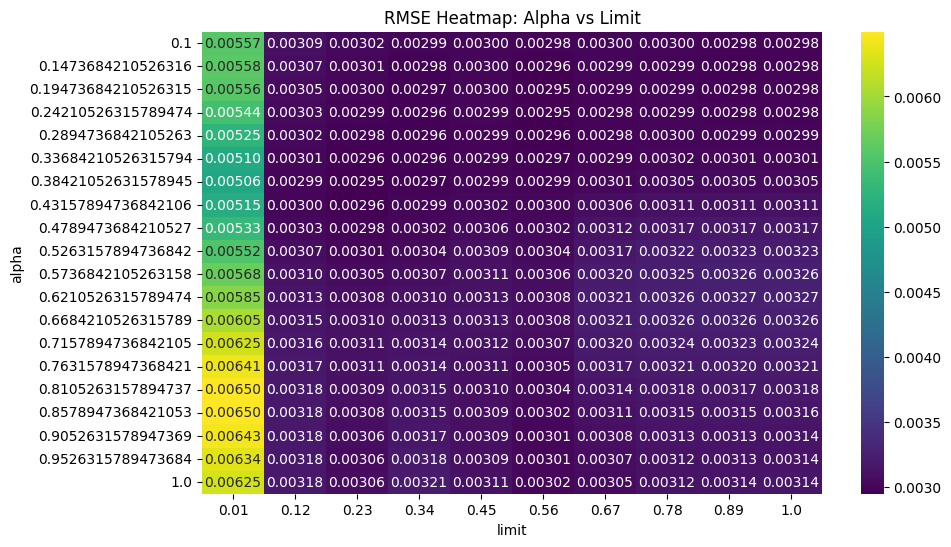

In [26]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Convert to DataFrame for easier visualization
df_results = pd.DataFrame([
    (a, l, r) for a, l, r in results if isinstance(r, float)
], columns=["alpha", "limit", "rmse"])

# Pivot for heatmap
pivot_table = df_results.pivot(index="alpha", columns="limit", values="rmse")

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt=".5f", cmap="viridis")
plt.title("RMSE Heatmap: Alpha vs Limit")
plt.show()

In [89]:
from ESN import ClassicalRC
CRM = ClassicalRC(input_size=len(X_train[0]), reservoir_size=150, spectral_radius=0.6, sparsity=0.1,noise=0.0001,use_reservoir=True)

In [90]:
alphas = [1,0.1,0.01,0.001,0.0001, 1e-5,1e-6]
mses=[]
predicts = []
for i in alphas:
    CRM.train(np.array(X_train), y_train, model_type="ridge", alpha=i)
    y_pred = CRM.predict(np.array(X_test))
    predicts.append(y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mses.append(mse)
    print("MSE:", mse, "RMSE:", np.sqrt(mse))

MSE: 0.002623867825983574 RMSE: 0.05122370375113043
MSE: 0.002719228662160229 RMSE: 0.05214622385331683
MSE: 0.0030997565408689013 RMSE: 0.05567545725783401
MSE: 0.0034007269008475226 RMSE: 0.0583157517386814
MSE: 0.0035182502062632635 RMSE: 0.05931483967999293
MSE: 0.0034661859723696324 RMSE: 0.05887432354065423
MSE: 0.0034900053276224214 RMSE: 0.05907626704204


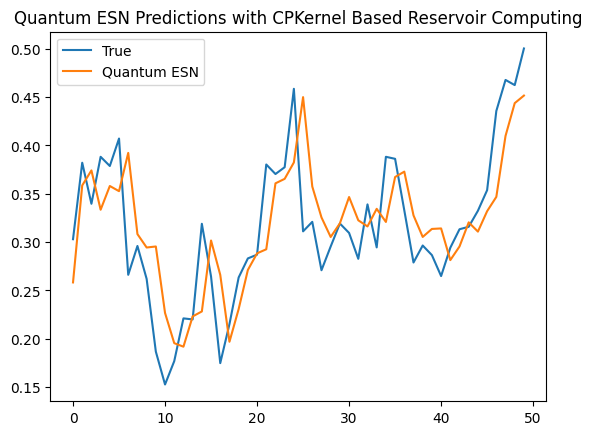

In [91]:
a = 0
b = 50
# Plot Predictions
plt.plot(y_test[a:a+b], label="True")
plt.plot(predicts[0][a:a+b], label="Quantum ESN")
plt.title("Quantum ESN Predictions with CPKernel Based Reservoir Computing")
plt.legend()
plt.show()

In [30]:
type(y_pred)

numpy.ndarray